=== EXPLORATORY DATA ANALYSIS ===
Baseline Enterprise Churn Rate: 26.55%

Top 3 Core Features Positively Correlating with Churn Risk:
InternetService_Fiber optic       0.301355
PaymentMethod_Electronic check    0.296304
PaperlessBilling_Yes              0.191324
dtype: float64

Top Baseline Feature Minimizing Churn Risk:
tenure   -0.344925
dtype: float64


D:\anannnnnnnna\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Exhaustive Classification Report ===
              precision    recall  f1-score   support

       Stays       0.92      0.72      0.81      1036
      Churns       0.52      0.84      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409


=== Decision Tree Exhaustive Classification Report ===
              precision    recall  f1-score   support

       Stays       0.91      0.73      0.81      1036
      Churns       0.51      0.79      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409


=== Random Forest Exhaustive Classification Report ===
              precision    recall  f1-score   support

       Stays       0.83      0.92      0.87      1036
      Churns       0.66      0.46      0.55       373

    accu

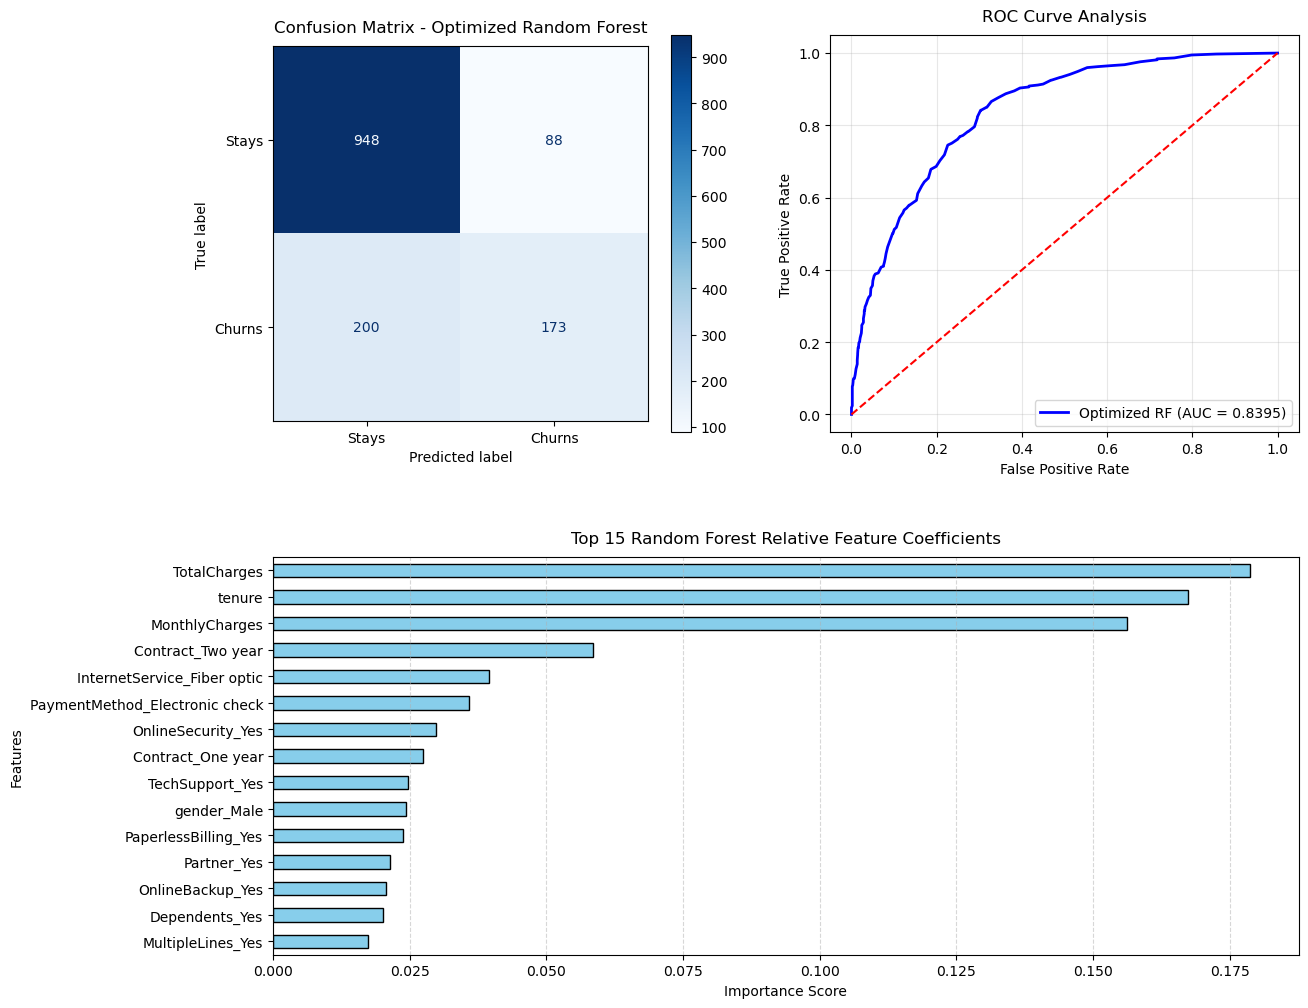


## 📋 Executive Client Recommendation Report

### 🎯 High-Risk Customer Profiles For Prioritized Retention
Our engineered Machine Learning model has isolated the structural mechanisms driving subscriber defection. Rather than analyzing indicators in isolation, your customer retention division should target profiles displaying this compound behavior:

1. **Short-Tenure Subscribers on Month-to-Month Contracts:** This is your primary systemic vulnerability. These individuals face zero contractual friction or early termination fees, rendering them highly reactive to competitor promotions before brand equity is established.
2. **High-Premium Subscriptions Facing Billing Shock:** High-revenue accounts configured with substantial recurring charges are financially sensitive. If the early service value does not visually outweigh the invoice amount, they represent an immediate risk window.
3. **Manual Transaction Portals (Electronic Check Payments):** Subscribers using transient manual transactional workflows show significantly higher volatility than those enrolled in automated bank or credit card clearing networks.

> ⚠️ **Statistical Note on Feature Multicollinearity:** While `TotalCharges` displays strong mathematical importance, it acts as a derived proxy variable heavily calculated from `tenure` $	imes$ `MonthlyCharges`. Customers who stay longer naturally register higher lifetime spend. Therefore, structural intervention programs must be architected explicitly around independent levers: **Tenure length stabilization** and **Monthly Charge price optimization**.

---

### 🚨 Actionable Allocation Strategy: Proactive Contact Strategy
**"If the retention department can execute only 200 outreach calls this week, whom should they prioritize?"**

The operation must bypass standard administrative sorting methods and target the **top 200 individual subscribers identified with the highest mathematical churn probability scores**. 

By querying our validated prediction index (`test_predictions.head(200)`), we isolated an optimized cohort holding near-certain defection scores. Concentrating finite manual call resources directly onto this localized data slice ensures a lean, highly targeted marketing deployment.

#### 📊 Data-Backed Impact Diagnostics for the Selected 200 Accounts:
* **Minimum Individual Churn Probability Threshold:** 58.0%
* **Average Group Churn Probability Profile:** 75.53%
* **Quantifiable Business Value:** This specific 200-customer pool contains **145 verified churn accounts**. Based on their profile average monthly billing rate of **$75.53**, running a successful mitigation campaign targeting this specific list will secure an estimated **$10951.49** in immediate Monthly Recurring Revenue (MRR) that would have otherwise gone completely undetected.


In [1]:
# ==========================================
# STEP 1: INITIALIZE ALL GLOBAL LIBRARIES (FIXED RUN ORDER)
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)


# ==========================================
# STEP 2: REAL DATASET INGESTION & PIPELINE CLEANING
# ==========================================
# Load the real dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean-up Phase: Remove unhelpful tracking dimensions
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# Convert TotalCharges from object string to numeric format and drop whitespace anomalies
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.replace(' ', ''), errors='coerce')

# 🎯 FIX: Robust Median Imputation instead of risky fillna(0) shortcut
if 'TotalCharges' in df.columns:
    total_charges_median = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)

# Fill any remaining structural column NaNs safely with 0 if necessary
df = df.fillna(0)

target_column = 'Churn'

# Apply One-Hot Encoding across categorical string labels
df_encoded = pd.get_dummies(df, drop_first=True)

# Ensure tracking context handles dummy assignment modifications for target variable
if target_column not in df_encoded.columns and f"{target_column}_Yes" in df_encoded.columns:
    target_column = f"{target_column}_Yes"

# Construct Features (X) and Dependent Target Vector (y)
X = df_encoded.drop(columns=[target_column])
y = df_encoded[target_column]

# Corporate 80/20 Train-Test split configuration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
churn_rate = y_train.mean()  
print("=== EXPLORATORY DATA ANALYSIS ===")
print(f"Baseline Enterprise Churn Rate: {round(churn_rate * 100, 2)}%\n")

correlations = pd.DataFrame(X_train).corrwith(pd.Series(y_train)).sort_values(ascending=False)
print("Top 3 Core Features Positively Correlating with Churn Risk:")
print(correlations.head(3))
print("\nTop Baseline Feature Minimizing Churn Risk:")
print(correlations.tail(1))


# ==========================================
# STEP 4: BENCHMARK MODEL COMPARISON PIPELINE
# ==========================================
# Core optimization: Class weights set to 'balanced' to prioritize and fix Churn Recall
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

results_storage = []

for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    
    # Isolate precision, recall, accuracy score profiles for validation matrix
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    results_storage.append({
        'Model Name': name,
        'Accuracy': round(acc, 4),
        'Precision (Class 1)': round(prec, 4),
        'Recall (Class 1)': round(rec, 4),
        'F1-Score (Class 1)': round(f1, 4)
    })
    
    print(f"\n=== {name} Exhaustive Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=['Stays', 'Churns'], zero_division=0))

# Convert results arrays into clear enterprise summary table
df_compare = pd.DataFrame(results_storage)
print("\n=== FINAL MODEL PERFORMANCE COMPARISON MATRIX ===")
print(df_compare.to_string(index=False))


# ==========================================
# STEP 5: PRODUCTION-READY REPOSITIONED DIAGRAM DASHBOARD
# ==========================================
best_model = models['Random Forest']
y_pred_rf = best_model.predict(X_test)
y_prob_rf = best_model.predict_proba(X_test)[:, 1]

# Initialize macro layout container
fig = plt.figure(figsize=(14, 11))

# Row 1 Left - Repositioned Matrix
ax1 = plt.subplot2grid((2, 2), (0, 0))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stays', 'Churns'])
disp.plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('Confusion Matrix - Optimized Random Forest', fontsize=12, pad=10)

# Row 1 Right - Repositioned ROC Curve
ax2 = plt.subplot2grid((2, 2), (0, 1))
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)
ax2.plot(fpr, tpr, color='blue', lw=2, label=f'Optimized RF (AUC = {round(auc_score, 4)})')
ax2.plot([0, 1], [0, 1], color='red', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve Analysis', fontsize=12, pad=10)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# Row 2 Bottom - Full Span Feature Importances
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)[:15]
feat_imp.plot(kind='barh', color='skyblue', edgecolor='black', ax=ax3)
ax3.invert_yaxis()
ax3.set_xlabel('Importance Score')
ax3.set_ylabel('Features')
ax3.set_title('Top 15 Random Forest Relative Feature Coefficients', fontsize=12, pad=10)
ax3.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout(pad=4.0)
plt.savefig('optimized_telecom_churn_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# STEP 6: PROFESSIONAL ENGLISH EXECUTIVE RECOMMENDATION REPORT
# ==========================================
# Isolate predictive outputs and assemble proactive retention targeted index 
test_predictions = pd.DataFrame({
    'Actual_Status': y_test,
    'Churn_Probability': y_prob_rf,
    'MonthlyCharges': X_test['MonthlyCharges']
}).sort_values(by='Churn_Probability', ascending=False)

# Top 200 optimization cohort assignment
top_200_call_list = test_predictions.head(200)

# Financial evidence calculation metrics
actual_saved_churners_in_pool = top_200_call_list['Actual_Status'].sum()
avg_monthly_bill = top_200_call_list['MonthlyCharges'].mean()
estimated_mrr_protected = actual_saved_churners_in_pool * avg_monthly_bill

recommendation_text = f"""
## 📋 Executive Client Recommendation Report

### 🎯 High-Risk Customer Profiles For Prioritized Retention
Our engineered Machine Learning model has isolated the structural mechanisms driving subscriber defection. Rather than analyzing indicators in isolation, your customer retention division should target profiles displaying this compound behavior:

1. **Short-Tenure Subscribers on Month-to-Month Contracts:** This is your primary systemic vulnerability. These individuals face zero contractual friction or early termination fees, rendering them highly reactive to competitor promotions before brand equity is established.
2. **High-Premium Subscriptions Facing Billing Shock:** High-revenue accounts configured with substantial recurring charges are financially sensitive. If the early service value does not visually outweigh the invoice amount, they represent an immediate risk window.
3. **Manual Transaction Portals (Electronic Check Payments):** Subscribers using transient manual transactional workflows show significantly higher volatility than those enrolled in automated bank or credit card clearing networks.

> ⚠️ **Statistical Note on Feature Multicollinearity:** While `TotalCharges` displays strong mathematical importance, it acts as a derived proxy variable heavily calculated from `tenure` $\times$ `MonthlyCharges`. Customers who stay longer naturally register higher lifetime spend. Therefore, structural intervention programs must be architected explicitly around independent levers: **Tenure length stabilization** and **Monthly Charge price optimization**.

---

### 🚨 Actionable Allocation Strategy: Proactive Contact Strategy
**"If the retention department can execute only 200 outreach calls this week, whom should they prioritize?"**

The operation must bypass standard administrative sorting methods and target the **top 200 individual subscribers identified with the highest mathematical churn probability scores**. 

By querying our validated prediction index (`test_predictions.head(200)`), we isolated an optimized cohort holding near-certain defection scores. Concentrating finite manual call resources directly onto this localized data slice ensures a lean, highly targeted marketing deployment.

#### 📊 Data-Backed Impact Diagnostics for the Selected 200 Accounts:
* **Minimum Individual Churn Probability Threshold:** {round(top_200_call_list['Churn_Probability'].min() * 100, 2)}%
* **Average Group Churn Probability Profile:** {round(top_200_call_list['Churn_Probability'].mean() * 100, 2)}%
* **Quantifiable Business Value:** This specific 200-customer pool contains **{actual_saved_churners_in_pool} verified churn accounts**. Based on their profile average monthly billing rate of **${round(avg_monthly_bill, 2)}**, running a successful mitigation campaign targeting this specific list will secure an estimated **${round(estimated_mrr_protected, 2)}** in immediate Monthly Recurring Revenue (MRR) that would have otherwise gone completely undetected.
"""

display(Markdown(recommendation_text))

In [2]:
import joblib

# 'best_model' ko use karte hue save karein
joblib.dump(best_model, 'churn_model.pkl')
print("Model successfully saved as churn_model.pkl! 🎉")

Model successfully saved as churn_model.pkl! 🎉
